# Fase 1 — Análise Descritiva: Candidatos 2026 (TSE)

Esta fase é **exploração pura**: olhar para os dados de candidatos e de bens declarados sem nenhum compromisso com o que vem depois (clusterização, regras de associação, anomalias). A ideia é conhecer o dataset por conta própria — distribuições, proporções, outliers, relações entre variáveis — **antes** de qualquer modelo apontar o que "importa". As fases seguintes vão te pedir pra escolher variáveis; essa escolha deve nascer do que você observar aqui, não o contrário.

Este notebook parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## Configuração

Use os **mesmos valores** que você usou na Fase 0, para carregar o arquivo certo.

In [1]:
CARGO = "DEPUTADO FEDERAL"
UF = ['DF', 'GO', 'MT', 'MS']
ANO_ELEICAO = 2026

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)

nome_uf = 'CENTRO_OESTE'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_DEPUTADO_FEDERAL_CENTRO_OESTE_2026.csv  ->  692 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532001,3022,ALESSANDRA ALMEIDA CHIANELLI DUTRA,ALE CHIANELLI,#NULO,58442472134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,DF,1972-11-28,11236642070,4,FEMININO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.00,"130,000.00",0.00,0.00,0.00,0.00,"130,000.00",11.78,53
1,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532002,3012,PAULO CESAR ECHEBARRIA DE CARVALHO,PAULO ECHEBARRIA,#NULO,37959077134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1965-10-20,7033782089,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.00,"380,000.00",0.00,0.00,0.00,"15,000,000.00","15,380,000.00",16.55,60
2,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532003,3004,FLAVIO HENRIQUE TORMINN FLEURY,FLAVIO FLEURY,#NULO,88847560144,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1981-09-01,46935651074,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,114,FISIOTERAPEUTA E TERAPEUTA OCUPACIONAL,-1,#NULO,0.00,"53,000.00",0.00,0.00,0.00,0.00,"53,000.00",10.88,45
3,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532004,3030,CARINE TEIXEIRA MARQUES,CARINE TEIXEIRA,#NULO,1642767182,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1986-08-25,52572671066,4,FEMININO,8,SUPERIOR COMPLETO,3,CASADO(A),2,PRETA,257,EMPRESÁRIO,-1,#NULO,0.00,0.00,0.00,0.00,"120,000.00",0.00,"120,000.00",11.70,40
4,08/09/2026,16:30:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532005,3010,EMILIO KERBER FILHO,EMILIO KERBER,#NULO,92759130053,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,PR,1976-08-31,263044410167,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,185,ESCRITOR E CRÍTICO,-1,#NULO,"1,380,000.00",0.00,0.00,0.00,0.00,0.00,"1,380,000.00",14.14,50


## 1) Visão geral: tamanho, tipos e dados ausentes

Antes de olhar variável por variável, um raio-x da tabela inteira.

692 candidatos x 59 colunas



str        31
int64      20
float64     8
Name: nº de colunas, dtype: int64

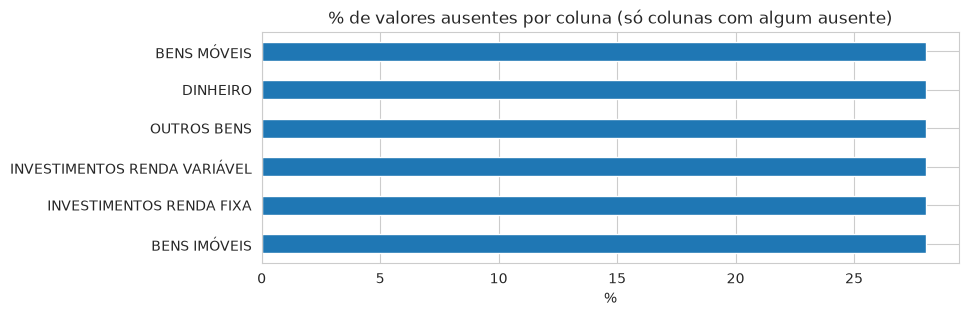

In [3]:
print(f"{df.shape[0]} candidatos x {df.shape[1]} colunas\n")
display(df.dtypes.value_counts().rename('nº de colunas'))

faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    plt.figure(figsize=(9, max(3, len(faltantes) * 0.3)))
    faltantes.plot(kind='barh')
    plt.title('% de valores ausentes por coluna (só colunas com algum ausente)')
    plt.xlabel('%')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2) Escolhendo o que explorar

O dataset tem dezenas de colunas — muitas são identificadores administrativos (`SQ_CANDIDATO`, `NR_CPF_CANDIDATO`, `DS_EMAIL`, hashes de geração...) sem valor analítico. As duas listas abaixo reúnem as colunas com conteúdo substantivo — **sintam-se livres para adicionar outras que despertarem curiosidade** (`df.columns` mostra tudo o que está disponível).

In [4]:
display(pd.DataFrame({"Coluna": df.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,ANO_ELEICAO
3,CD_TIPO_ELEICAO
4,NM_TIPO_ELEICAO
5,NR_TURNO
6,CD_ELEICAO
7,DS_ELEICAO
8,DT_ELEICAO
9,TP_ABRANGENCIA


In [5]:
colunas_numericas = [
    'IDADE',
    'Total_Bens',
    'Total_Bens_Log',
    'BENS MÓVEIS',
    'BENS IMÓVEIS',
    'DINHEIRO',
    'INVESTIMENTOS RENDA FIXA',
    'INVESTIMENTOS RENDA VARIÁVEL',
    'OUTROS BENS',
]
colunas_numericas = [c for c in colunas_numericas if c in df.columns]

colunas_categoricas = [
    'DS_GENERO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA',
    'DS_GRAU_INSTRUCAO',
    'DS_SITUACAO_CANDIDATURA',
    'DS_SIT_TOT_TURNO',
    'TP_AGREMIACAO',
    'SG_PARTIDO',
    'DS_OCUPACAO',
    'NR_TURNO',
    'SG_UE',
]
colunas_categoricas = [c for c in colunas_categoricas if c in df.columns]

print("Numéricas:")
display(pd.DataFrame({"Coluna": colunas_numericas}))
print("Categóricas:")
display(pd.DataFrame({"Coluna": colunas_categoricas}))

Numéricas:


,Coluna
0,IDADE
1,Total_Bens
2,Total_Bens_Log
3,BENS MÓVEIS
4,BENS IMÓVEIS
5,DINHEIRO
6,INVESTIMENTOS RENDA FIXA
7,INVESTIMENTOS RENDA VARIÁVEL
8,OUTROS BENS


Categóricas:


,Coluna
0,DS_GENERO
1,DS_ESTADO_CIVIL
2,DS_COR_RACA
3,DS_GRAU_INSTRUCAO
4,DS_SITUACAO_CANDIDATURA
5,DS_SIT_TOT_TURNO
6,TP_AGREMIACAO
7,SG_PARTIDO
8,DS_OCUPACAO
9,NR_TURNO


## 3) Variáveis numéricas: distribuição e outliers

In [6]:
display(df[colunas_numericas].describe().T)

,count,mean,std,min,25%,50%,75%,max
IDADE,692.00,48.57,12.51,21.00,40.00,48.00,57.00,86.00
Total_Bens,692.00,"1,951,439.81","8,181,165.69",0.00,0.00,"208,700.00","970,437.10","103,733,556.02"
Total_Bens_Log,692.00,9.41,6.09,0.00,0.00,12.25,13.79,18.46
BENS MÓVEIS,498.00,"347,124.70","4,301,330.16",0.00,0.00,"38,750.00","139,125.00","95,000,000.00"
BENS IMÓVEIS,498.00,"804,424.55","2,368,881.75",0.00,0.00,"235,171.32","800,000.00","35,528,057.35"
DINHEIRO,498.00,"57,257.95","370,337.37",0.00,0.00,0.00,"1,348.66","5,275,341.98"
INVESTIMENTOS RENDA FIXA,498.00,"181,341.63","1,896,525.00",0.00,0.00,0.00,0.00,"33,057,038.00"
INVESTIMENTOS RENDA VARIÁVEL,498.00,"351,289.00","3,193,887.07",0.00,0.00,0.00,0.00,"65,018,864.00"
OUTROS BENS,498.00,"970,201.42","5,062,359.76",0.00,0.00,0.00,"120,000.00","73,979,450.00"


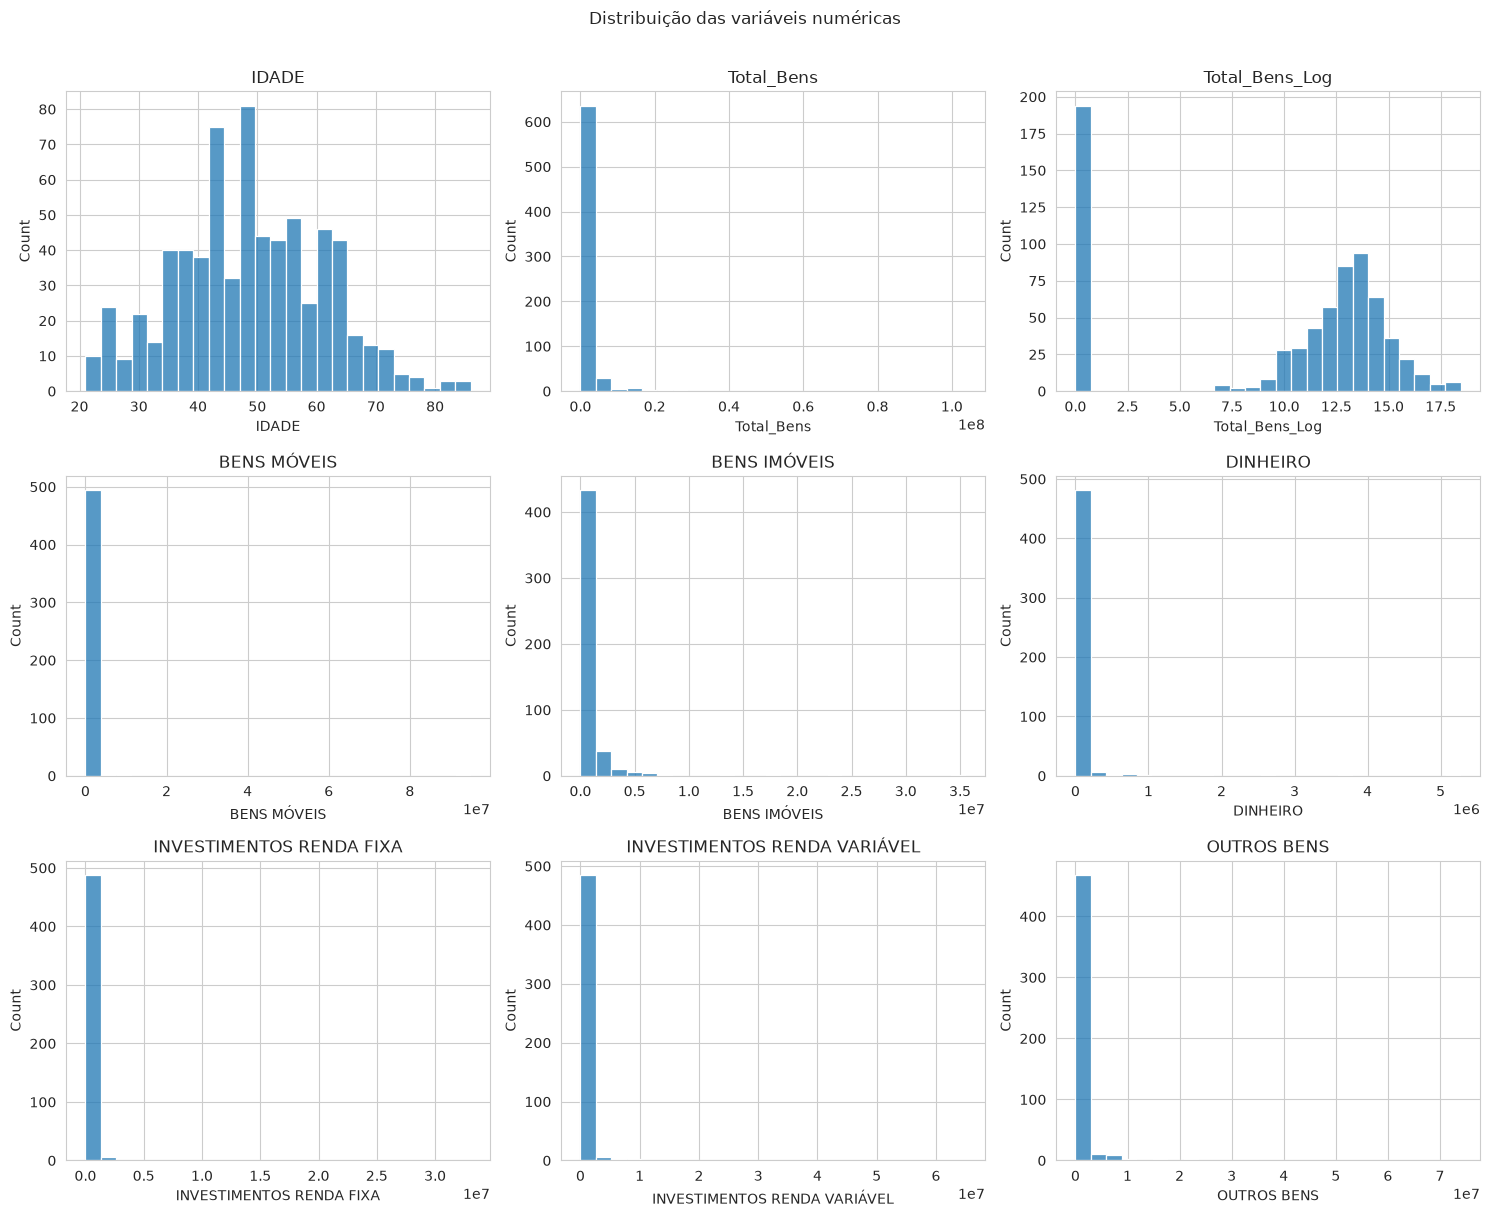

In [7]:
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.histplot(df[col], bins=25, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.01)
plt.tight_layout()
plt.show()

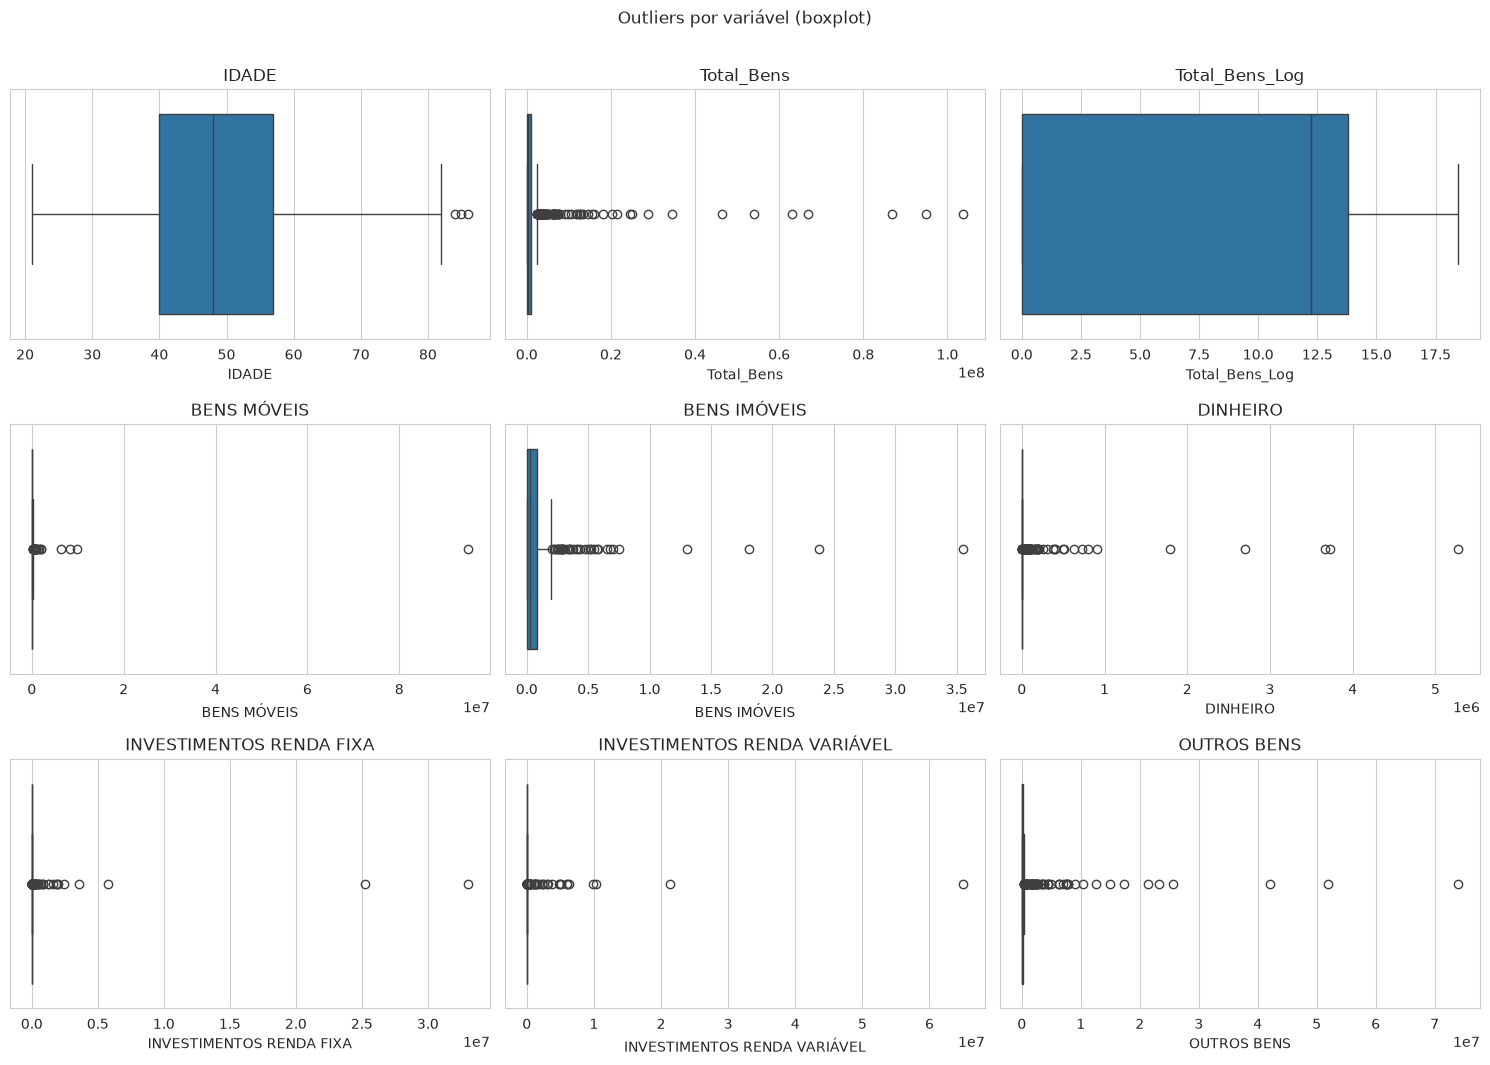

In [8]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outliers por variável (boxplot)', y=1.01)
plt.tight_layout()
plt.show()

### 3.1) Quantificando os outliers (regra do IQR)

O boxplot mostra visualmente; esta tabela quantifica: quantos candidatos ficam fora do intervalo `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` em cada variável.

In [9]:
linhas = []
for col in colunas_numericas:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    linhas.append({
        'variavel': col, 'limite_inferior': lim_inf, 'limite_superior': lim_sup,
        'qtd_outliers': n_outliers, 'pct_outliers': round(100 * n_outliers / len(df), 1),
    })

pd.DataFrame(linhas).sort_values('pct_outliers', ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,pct_outliers
6,INVESTIMENTOS RENDA FIXA,0.00,0.00,122,17.60
5,DINHEIRO,"-2,022.99","3,371.64",116,16.80
7,INVESTIMENTOS RENDA VARIÁVEL,0.00,0.00,104,15.00
1,Total_Bens,"-1,455,655.66","2,426,092.76",87,12.60
8,OUTROS BENS,"-180,000.00","300,000.00",84,12.10
3,BENS MÓVEIS,"-208,687.50","347,812.50",41,5.90
4,BENS IMÓVEIS,"-1,200,000.00","2,000,000.00",37,5.30
0,IDADE,14.50,82.50,3,0.40
2,Total_Bens_Log,-20.68,34.46,0,0.00


## 4) Variáveis categóricas: contagens e proporções

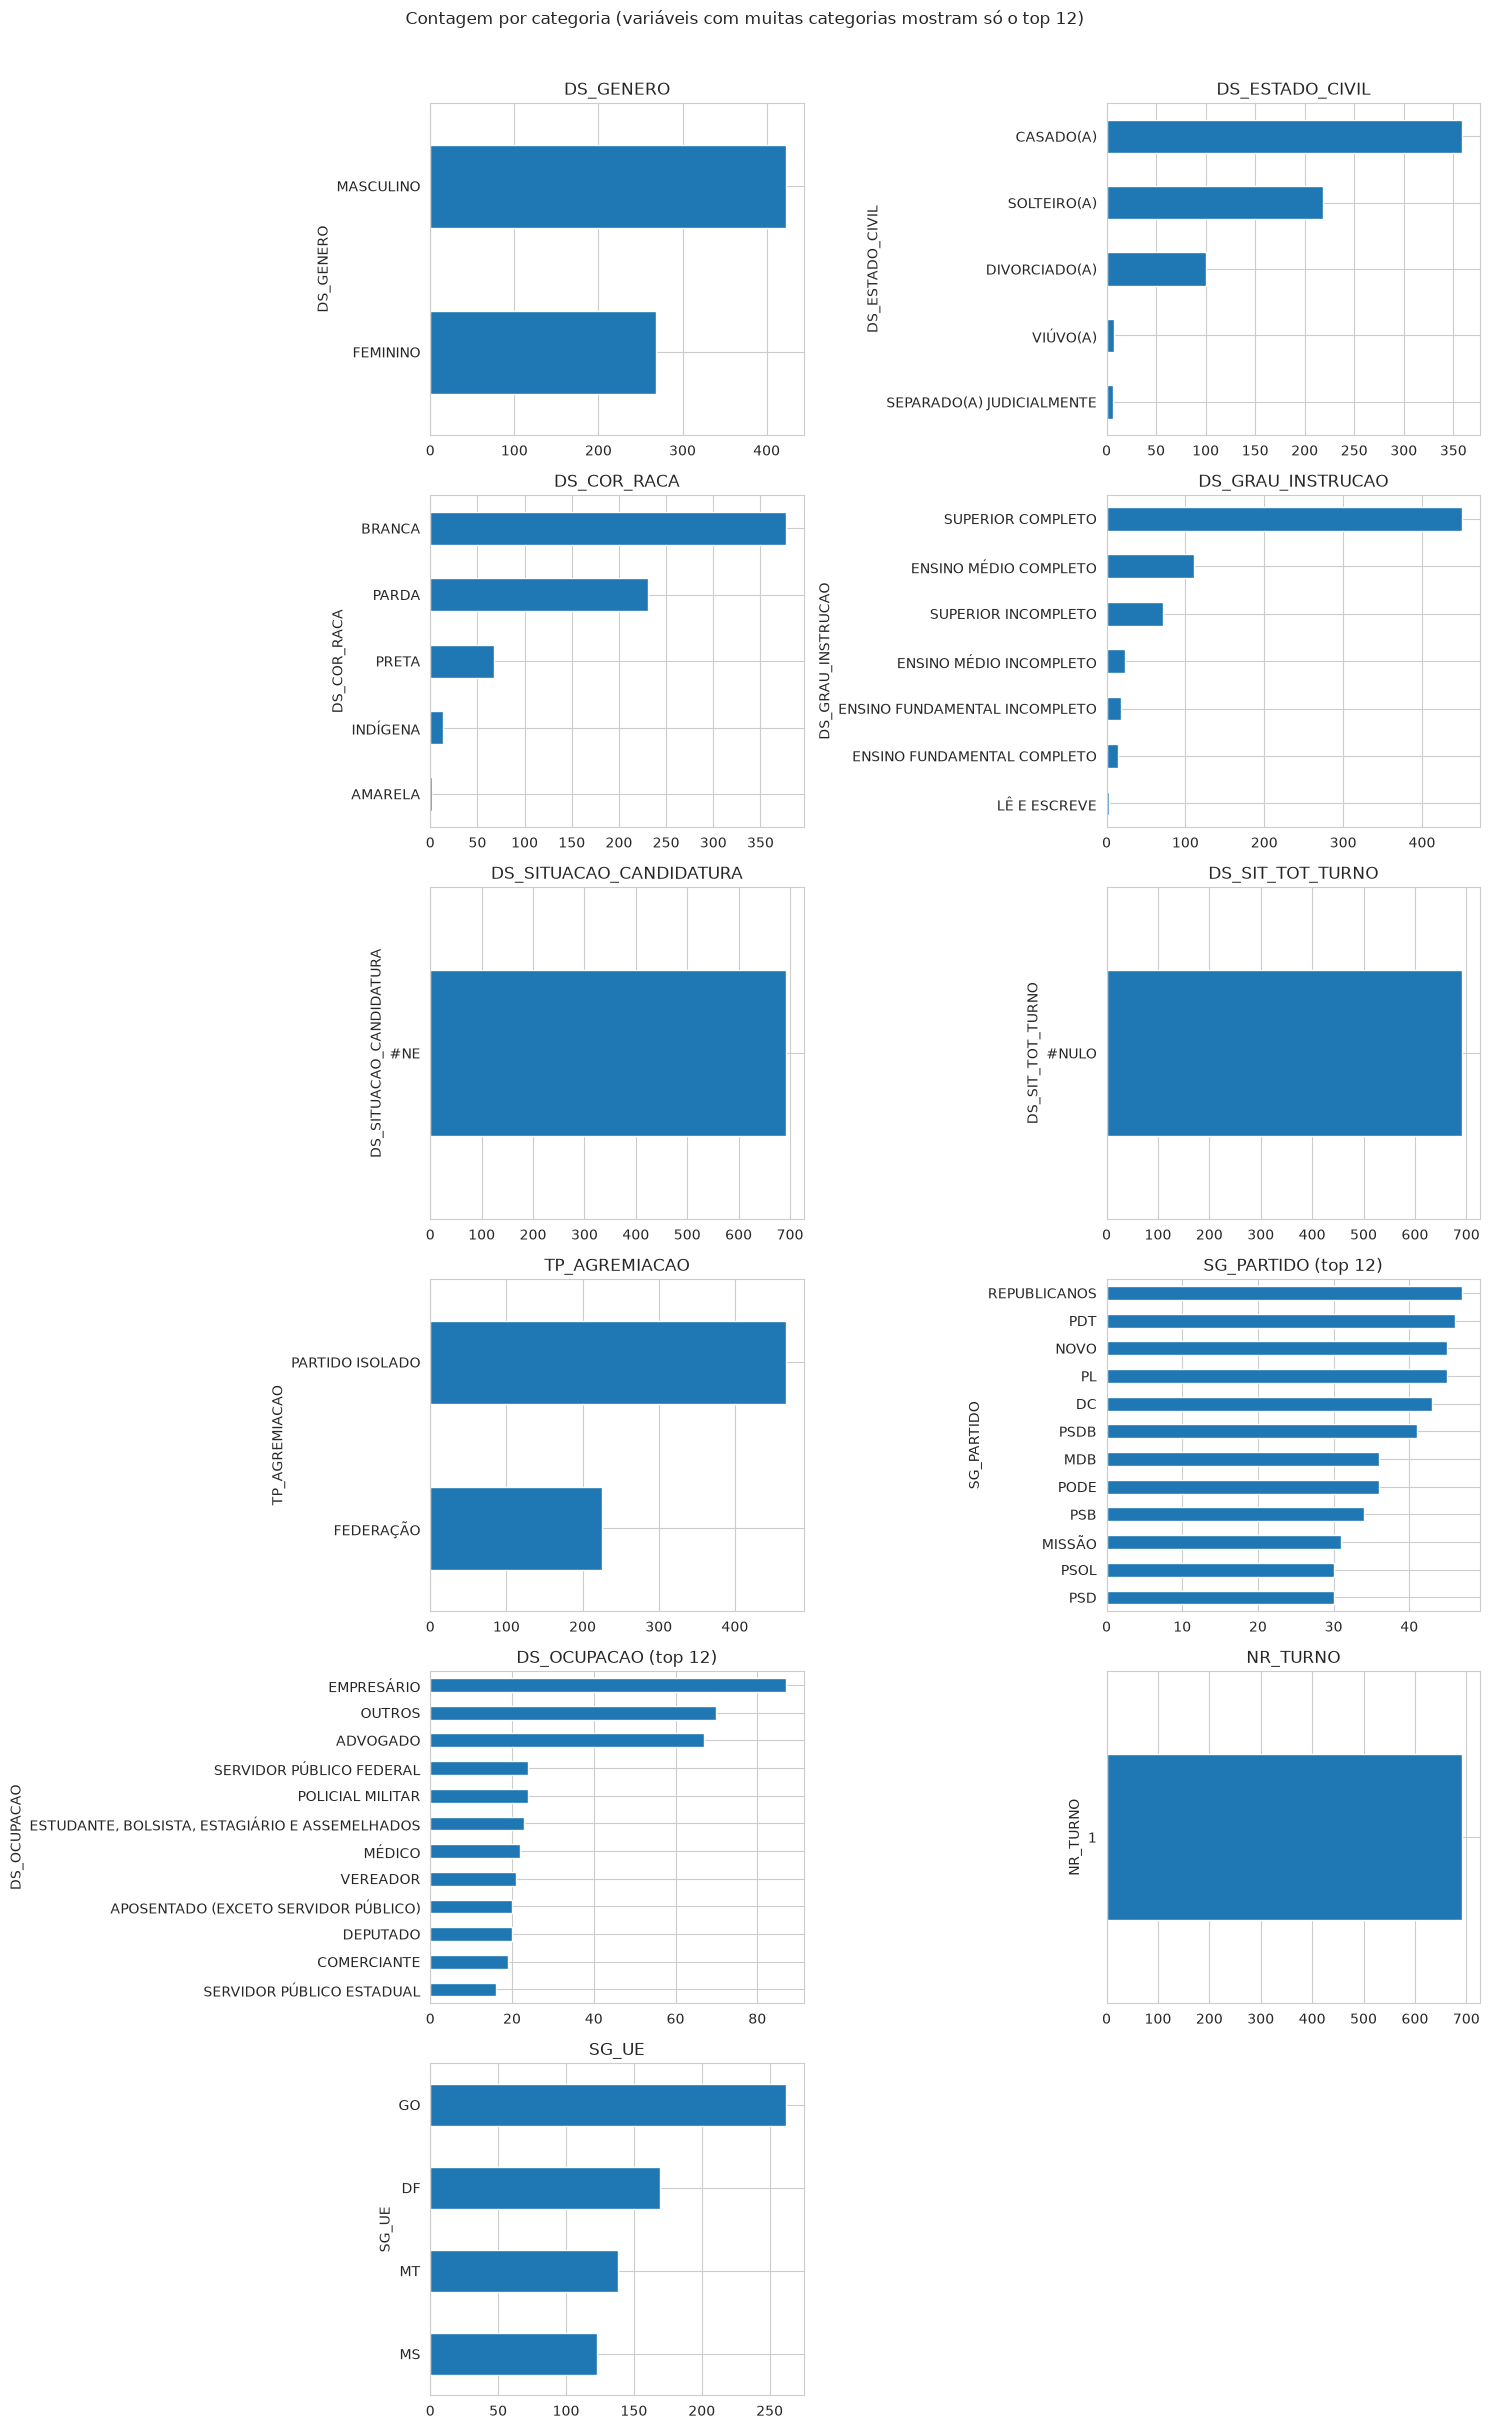

In [10]:
def plot_categorica(ax, coluna, top_n=12):
    contagem = df[coluna].value_counts().head(top_n)
    contagem.plot(kind='barh', ax=ax)
    ax.set_title(coluna + (f' (top {top_n})' if df[coluna].nunique() > top_n else ''))
    ax.invert_yaxis()

n = len(colunas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_categorica(axes[i], col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Contagem por categoria (variáveis com muitas categorias mostram só o top 12)', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
for col in colunas_categoricas:
    print(f"--- {col} ({df[col].nunique()} categorias) ---")
    print((df[col].value_counts(normalize=True).head(8) * 100).round(1).astype(str) + '%')
    print()

--- DS_GENERO (2 categorias) ---
DS_GENERO
MASCULINO    61.1%
FEMININO     38.9%
Name: proportion, dtype: str

--- DS_ESTADO_CIVIL (5 categorias) ---
DS_ESTADO_CIVIL
CASADO(A)                    51.9%
SOLTEIRO(A)                  31.5%
DIVORCIADO(A)                14.5%
VIÚVO(A)                      1.2%
SEPARADO(A) JUDICIALMENTE     1.0%
Name: proportion, dtype: str

--- DS_COR_RACA (5 categorias) ---
DS_COR_RACA
BRANCA      54.5%
PARDA       33.4%
PRETA        9.8%
INDÍGENA     2.0%
AMARELA      0.3%
Name: proportion, dtype: str

--- DS_GRAU_INSTRUCAO (7 categorias) ---
DS_GRAU_INSTRUCAO
SUPERIOR COMPLETO                65.2%
ENSINO MÉDIO COMPLETO            16.0%
SUPERIOR INCOMPLETO              10.4%
ENSINO MÉDIO INCOMPLETO           3.3%
ENSINO FUNDAMENTAL INCOMPLETO     2.6%
ENSINO FUNDAMENTAL COMPLETO       2.0%
LÊ E ESCREVE                      0.4%
Name: proportion, dtype: str

--- DS_SITUACAO_CANDIDATURA (1 categorias) ---
DS_SITUACAO_CANDIDATURA
#NE    100.0%
Name: proportio

## 5) Dispersão entre variáveis numéricas

Correlação e gráficos de dispersão par a par — sem nenhuma variável de destaque, só pra ver como as variáveis se relacionam (ou não).

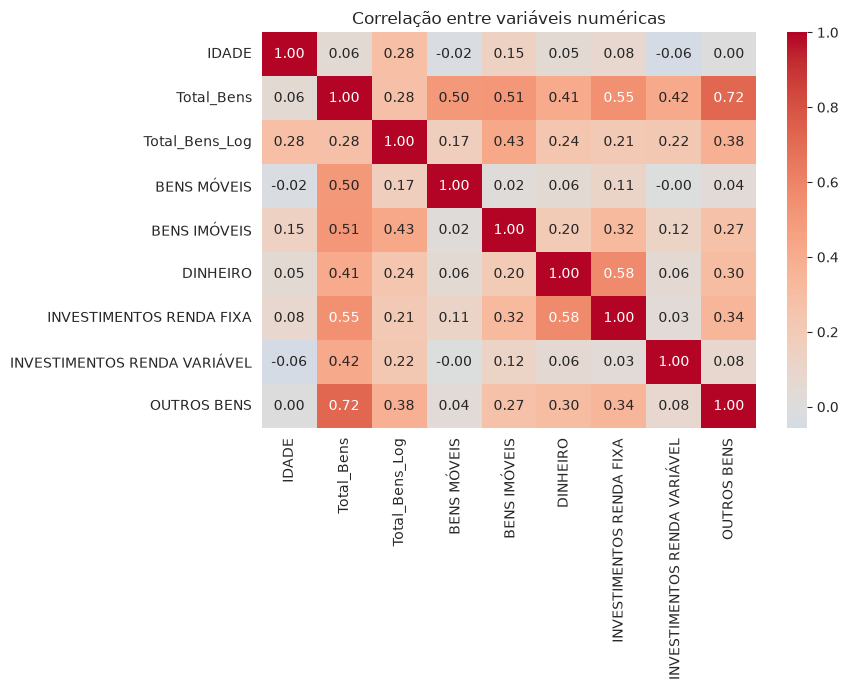

In [12]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

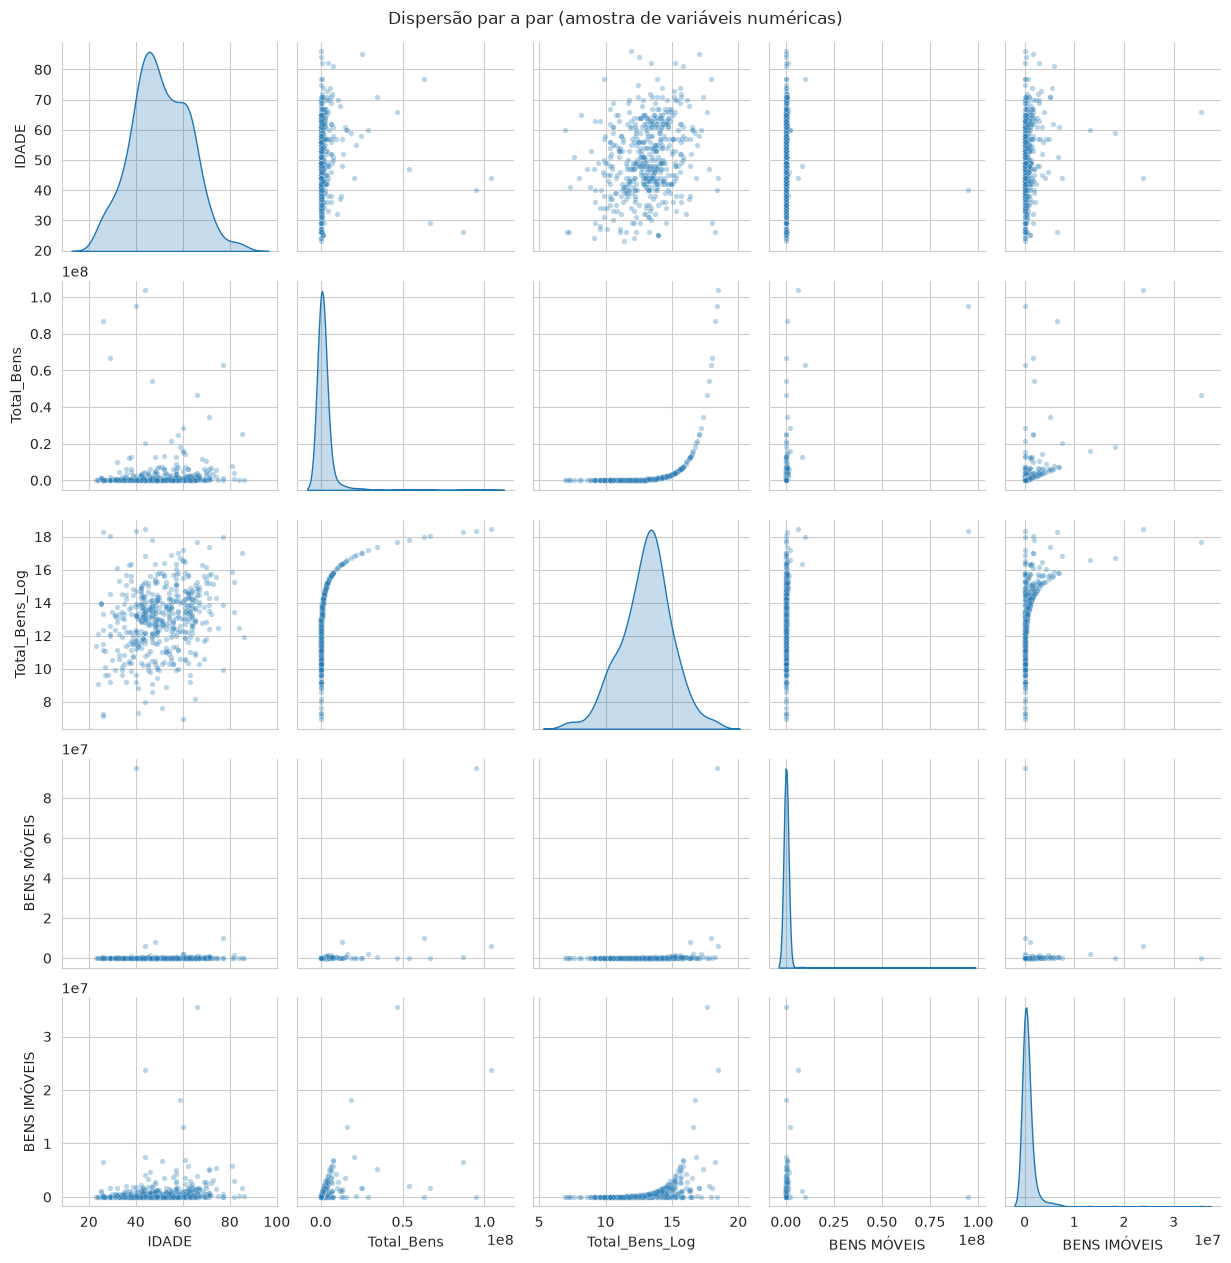

In [13]:
# Pairplot com um subconjunto (pairplot com muitas variáveis fica pesado/ilegível)
subset = colunas_numericas[:5]
sns.pairplot(df[subset].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Dispersão par a par (amostra de variáveis numéricas)', y=1.01)
plt.show()

### 5.1) Um exemplo de dispersão colorida

Só um exemplo de como cruzar uma variável numérica com outra numérica *e* uma categórica ao mesmo tempo — troquem `x`, `y` e `hue` livremente para explorar outras combinações.

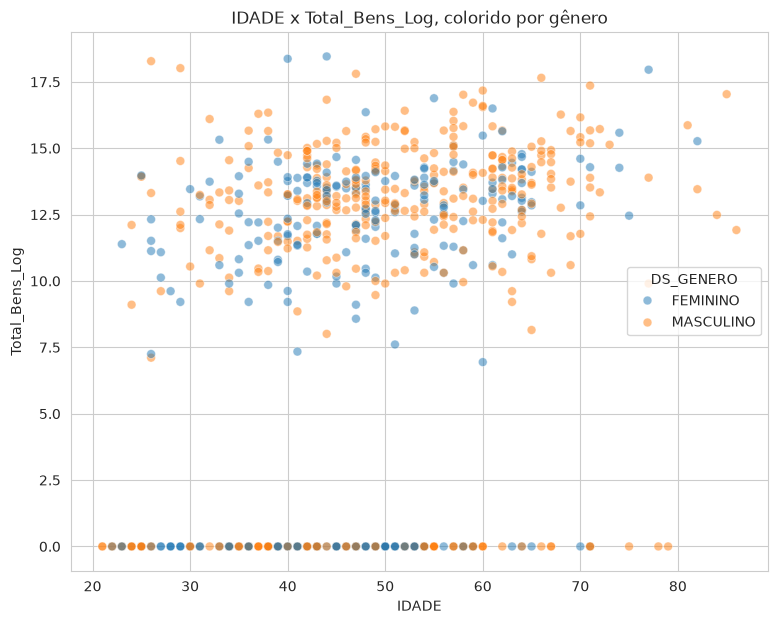

In [14]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='IDADE', y='Total_Bens_Log', hue='DS_GENERO', alpha=0.5, s=40)
plt.title('IDADE x Total_Bens_Log, colorido por gênero')
plt.show()

## 6) Proporções entre grupos

Alguns exemplos de cruzamentos categóricos — não são os únicos possíveis, só uma amostra do tipo de pergunta que dá pra fazer.

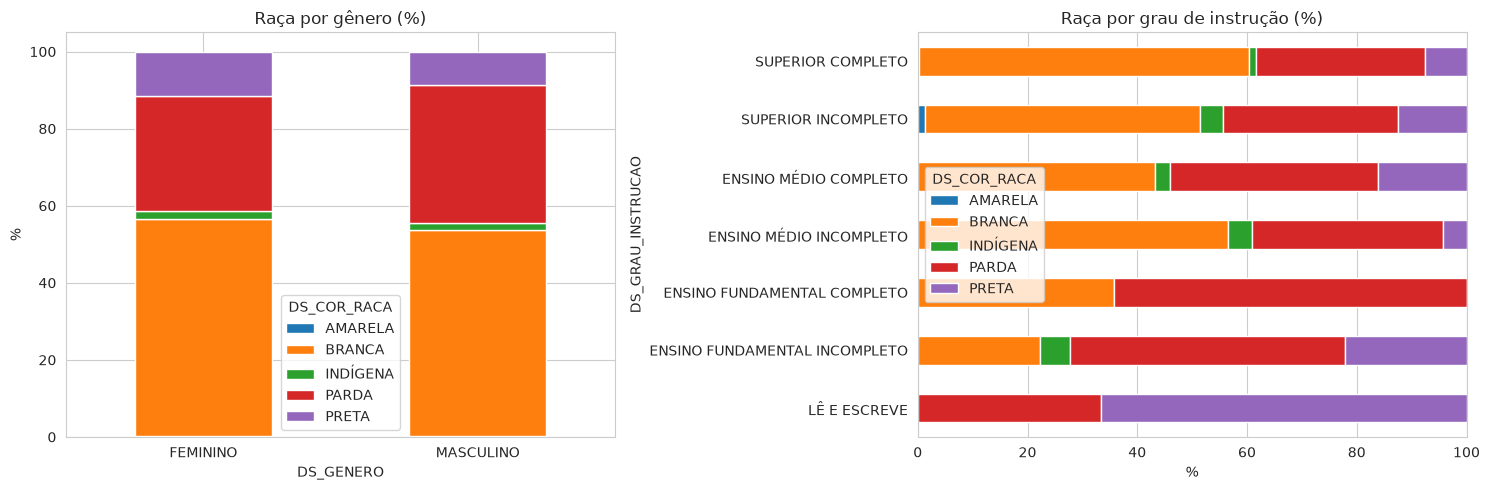

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df['DS_GENERO'], df['DS_COR_RACA'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0]
)
axes[0].set_title('Raça por gênero (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

ordem_instrucao = df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']].drop_duplicates().sort_values('CD_GRAU_INSTRUCAO')['DS_GRAU_INSTRUCAO']
pd.crosstab(df['DS_GRAU_INSTRUCAO'], df['DS_COR_RACA'], normalize='index').loc[ordem_instrucao].mul(100).plot(
    kind='barh', stacked=True, ax=axes[1]
)
axes[1].set_title('Raça por grau de instrução (%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

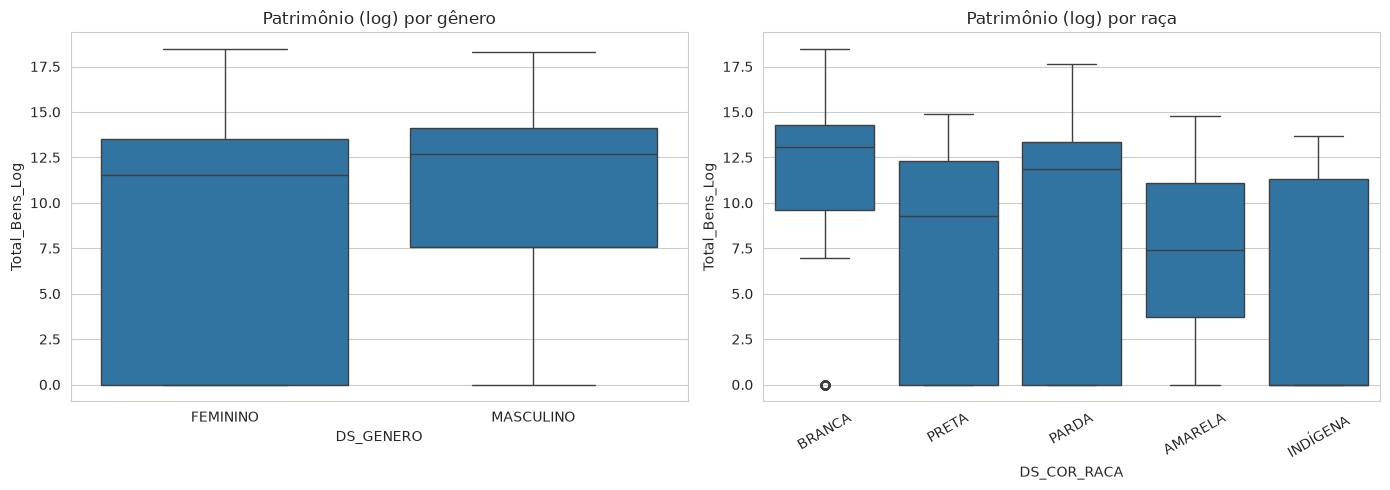

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GENERO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_COR_RACA', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

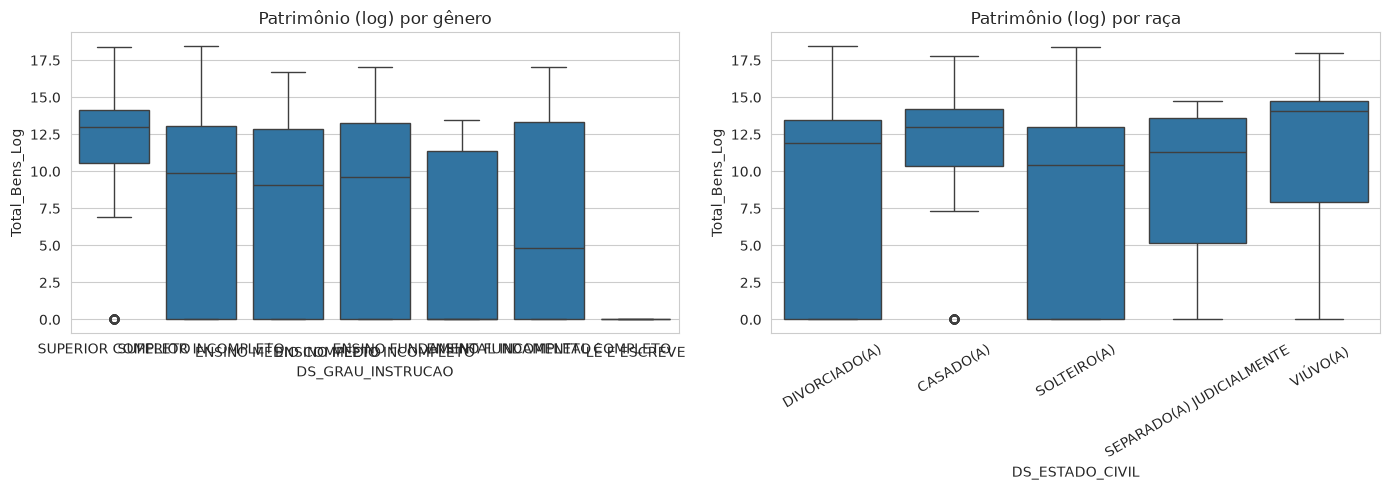

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GRAU_INSTRUCAO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_ESTADO_CIVIL', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

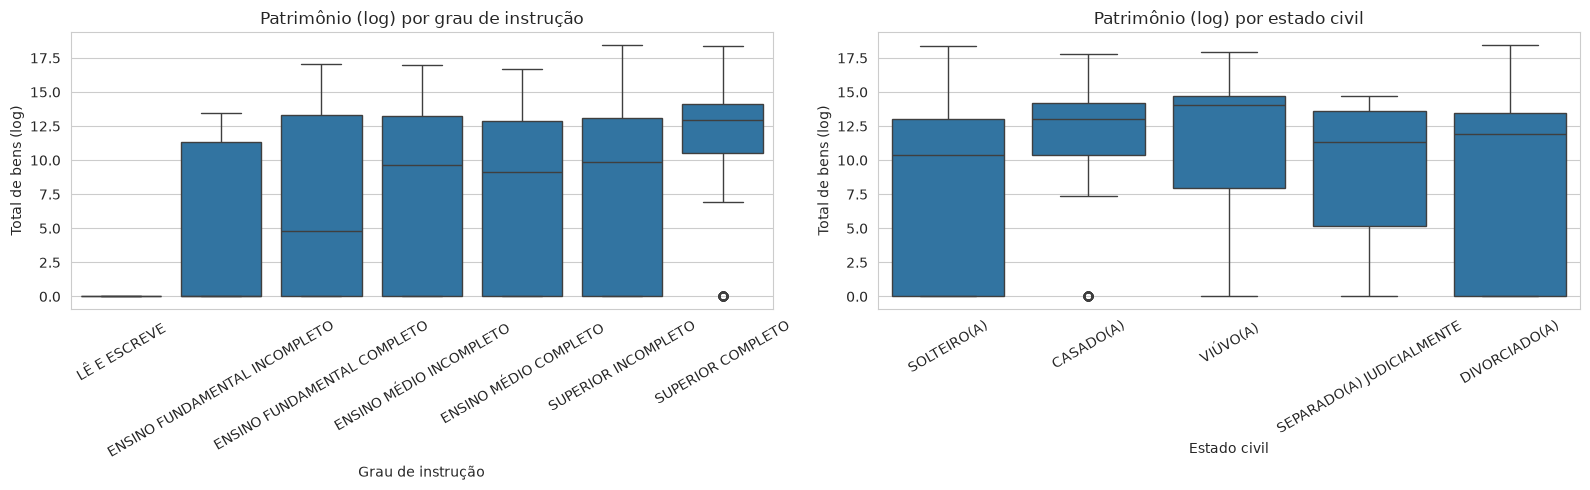

In [18]:
# Ordem do grau de instrução pelo respectivo código
ordem_instrucao = (
    df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']]
    .drop_duplicates()
    .sort_values('CD_GRAU_INSTRUCAO')
    ['DS_GRAU_INSTRUCAO']
    .tolist()
)

# Ordem do estado civil pelo respectivo código
ordem_estado_civil = (
    df[['CD_ESTADO_CIVIL', 'DS_ESTADO_CIVIL']]
    .drop_duplicates()
    .sort_values('CD_ESTADO_CIVIL')
    ['DS_ESTADO_CIVIL']
    .tolist()
)


# Cria os dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Grau de instrução
sns.boxplot(
    data=df,
    x='DS_GRAU_INSTRUCAO',
    y='Total_Bens_Log',
    order=ordem_instrucao,
    ax=axes[0]
)

axes[0].set_title('Patrimônio (log) por grau de instrução')
axes[0].set_xlabel('Grau de instrução')
axes[0].set_ylabel('Total de bens (log)')
axes[0].tick_params(axis='x', rotation=30)


# Estado civil
sns.boxplot(
    data=df,
    x='DS_ESTADO_CIVIL',
    y='Total_Bens_Log',
    order=ordem_estado_civil,
    ax=axes[1]
)

axes[1].set_title('Patrimônio (log) por estado civil')
axes[1].set_xlabel('Estado civil')
axes[1].set_ylabel('Total de bens (log)')
axes[1].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.show()

## 7) Comparação entre UFs

Esta seção só roda na visão **Brasil** (quando `UF = None`) — não se aplica ao recorte por estado.

In [19]:
if UF is None:
    resumo_uf = df.groupby('SG_UF').agg(
        qtd_candidatos=('SQ_CANDIDATO', 'count'),
        idade_media=('IDADE', 'mean'),
        patrimonio_mediano=('Total_Bens', 'median'),
        pct_feminino=('DS_GENERO', lambda x: (x == 'FEMININO').mean() * 100),
    ).round(1).sort_values('qtd_candidatos', ascending=False)

    display(resumo_uf)

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    resumo_uf['qtd_candidatos'].sort_values().plot(kind='barh', ax=axes[0])
    axes[0].set_title(f'Nº de candidatos a {CARGO} por UF')

    resumo_uf['patrimonio_mediano'].sort_values().plot(kind='barh', ax=axes[1], color='tab:orange')
    axes[1].set_title('Patrimônio mediano por UF (R$)')

    plt.tight_layout()
    plt.show()
else:
    print(f"UF = {UF!r} — seção não se aplica (dados já filtrados para uma única UF).")

UF = ['DF', 'GO', 'MT', 'MS'] — seção não se aplica (dados já filtrados para uma única UF).


---
## Fechamento

Este notebook não teve o objetivo de "preparar terreno" para nenhuma técnica específica — foi só olhar para os dados. Antes de seguir, escrevam algumas observações próprias: quais variáveis têm mais outliers? Alguma proporção chamou atenção? Alguma dispersão sugere relação entre variáveis (ou ausência dela)? Essas observações são o ponto de partida — não a conclusão — das próximas fases.

## Próximo passo

**Fase 2 — Clusterização** (K-Means, DBSCAN, hierárquico e Bisecting K-Means) — liberada em breve. A escolha de variáveis para essa fase parte do que vocês observaram aqui.